In [1]:
%%capture
!unset LD_PRELOAD
import os
os.environ.pop('LD_PRELOAD', None)

In [2]:
# !pip list all

In [7]:
# %%bash
# conda install -y -c conda-forge swig
# conda install -y -c conda-forge swig sdl2
# uv pip install "pygame==2.5.2"
# uv pip install "gymnasium[box2d]"
# uv pip install "gym[box2d]"
%pip install --upgrade pip
%pip install uv
# !uv pip install "pygame==2.1.0"
!uv pip install "gymnasium[box2d]"
# !uv pip install git+https://github.com/Farama-Foundation/Gymnasium.git

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Using Python 3.11.10 environment at: /opt/conda
Resolved 8 packages in 143ms                                         
░░░░░░░░░░░░░░░░░░░░ [0/2] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 2 packages in 1.66s                               
 + box2d-py==2.3.5
 + swig==4.3.1.post0


In [8]:
# import inspect

# try:
#     import gymnasium as gym
# except ImportError:
#     import gym

# env = gym.make("CarRacing-v3", render_mode="rgb_array", continuous=False)

# # unwrap to reach the base environment so we see the real step definition
# step_source = inspect.getsource(env.unwrapped.step)
# step_wrapped_source = inspect.getsource(env.step)
# # print(step_source)
# # print(step_wrapped_source)
# step_source == step_wrapped_source
# print(step_wrapped_source)

# import gymnasium as gym
# env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=False) # works if continuous=True

# env.reset()
# action = env.action_space.sample()
# observation, reward, terminated, truncated, info = env.step(action)

In [9]:
%%capture
%%bash 
pip install uv
uv pip install jupyter matplotlib numpy pandas torch==2.5.0 torchviz engression stable-baselines3 opencv-python # gymnasium 
# uv pip install "gym[box2d]" 
# uv pip install swig "gymnasium[box2d]"

# setup osmesa cpu backend for mujoco
conda install -c conda-forge mesalib
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa

uv pip install mujoco

In [10]:
# Minimal demo for calling env.step with CarRacing (Discrete actions)
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.box2d.car_dynamics import Car
from gymnasium.error import DependencyNotInstalled, InvalidAction
from gymnasium.utils import EzPickle
from types import MethodType


SCALE = 6.0  # Track scale
TRACK_RAD = 900 / SCALE  # Track is heavily morphed circle with this radius
PLAYFIELD = 2000 / SCALE  # Game over boundary
FPS = 50  # Frames per second
ZOOM = 2.7  # Camera zoom
ZOOM_FOLLOW = True  # Set to False for fixed view (don't use zoom)


def custom_step(self, action: np.ndarray | int):
        assert self.car is not None
        if action is not None:
            if self.continuous:
                action = action.astype(np.float64)
                self.car.steer(-action[0])
                self.car.gas(action[1])
                self.car.brake(action[2])
            else:
                if not self.action_space.contains(action):
                    raise InvalidAction(
                        f"you passed the invalid action `{action}`. "
                        f"The supported action_space is `{self.action_space}`"
                    )
                self.car.steer(-0.6 * (action == 1) + 0.6 * (action == 2))
                self.car.gas(0.2 * (action == 3))
                self.car.brake(0.8 * (action == 4))

        self.car.step(1.0 / FPS)
        self.world.Step(1.0 / FPS, 6 * 30, 2 * 30)
        self.t += 1.0 / FPS

        self.state = self._render("state_pixels")

        step_reward = 0
        terminated = False
        truncated = False
        info = {}
        if action is not None:  # First step without action, called from reset()
            self.reward -= 0.1
            # We actually don't want to count fuel spent, we want car to be faster.
            # self.reward -=  10 * self.car.fuel_spent / ENGINE_POWER
            self.car.fuel_spent = 0.0
            step_reward = self.reward - self.prev_reward
            self.prev_reward = self.reward
            if self.tile_visited_count == len(self.track) or self.new_lap:
                # Termination due to finishing lap
                terminated = True
                info["lap_finished"] = True
            x, y = self.car.hull.position
            if abs(x) > PLAYFIELD or abs(y) > PLAYFIELD:
                terminated = True
                info["lap_finished"] = False
                step_reward = -100

        if self.render_mode == "human":
            self.render()
        return self.state, step_reward, terminated, truncated, info


In [ ]:

# Create environment
env = gym.make("CarRacing-v3", render_mode="rgb_array", continuous=False)

# Bind your custom step method
env.unwrapped.step = MethodType(custom_step, env.unwrapped)

# Now use it
env.reset()
print(env.observation_space.shape)
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print(f"Reward: {reward}, Terminated: {terminated}")

(96, 96, 3)
Reward: 6.844444444444445, Terminated: False


In [ ]:
import torch
import numpy as np
import gymnasium as gym
import cv2 as cv
from typing import Union, Sequence, Tuple
import collections

from gymnasium.core import ActType, ObsType


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class InitialWrapper(gym.Wrapper):
    def __init__(self, env: gym.Env, no_ops: int = 0, repeat: int = 1):
        super(InitialWrapper, self).__init__(env)
        self.repeat = repeat
        self.no_ops = no_ops
        self.repeat = repeat

        self.op_counter = 0

    def step(self, action: ActType) -> Tuple[ObsType, float, bool, bool, dict]:
        if self.op_counter < self.no_ops:
            obs, reward, done, info = self.env.step(0)
            self.op_counter += 1

        total_reward = 0.0
        done = False
        for _ in range(self.repeat):
            obs, reward, done, info = self.env.step(action)
            total_reward += reward
            if done:
                break

        return obs, total_reward, done, info


class PreprocessFrame(gym.ObservationWrapper):
    def __init__(self, env: gym.Env, new_shape: Sequence[int] = (128, 128, 3), grayscale: bool = False):
        super(PreprocessFrame, self).__init__(env)
        self.shape = new_shape
        self.observation_space = gym.spaces.Box(low=0.0, high=1.0, shape=self.shape, dtype=np.float32)
        self.grayscale = grayscale

        if self.grayscale:
            self.observation_space = gym.spaces.Box(low=0.0, high=1.0, shape=(*self.shape[:-1], 1), dtype=np.float32)

    def observation(self, obs: torch.Tensor) -> torch.Tensor:
        obs = obs.astype(np.uint8)
        new_frame = cv.resize(obs, self.shape[:-1], interpolation=cv.INTER_AREA)
        if self.grayscale:
            new_frame = cv.cvtColor(new_frame, cv.COLOR_RGB2GRAY)
            new_frame = np.expand_dims(new_frame, -1)

        torch_frame = torch.from_numpy(new_frame).float()
        torch_frame = torch_frame / 255.0

        return torch_frame

def make_env(env_name: str, new_shape: Sequence[int] = (128, 128, 3), grayscale: bool = True, **kwargs):
    env = gym.make(env_name, **kwargs)
    env.unwrapped.step = MethodType(custom_step, env.unwrapped) # prevent coercing action to float type when continuous=False
    env = PreprocessFrame(env, new_shape, grayscale=grayscale)
    return env

if __name__ == "__main__":
    env = make_env("CarRacing-v3", render_mode="rgb_array", continuous=False)
    env.reset()
    print(env.observation_space.shape)
    print(env.action_space)

    env.step(np.int64(4))
    

(128, 128, 1)
Discrete(5)


In [ ]:
import torch
import torch.nn as nn
import torch.functional as F
from typing import Tuple

class EncoderCNN(nn.Module):
    def __init__(self, in_channels: int, embedding_dim: int = 2048, input_shape: Tuple[int, int] = (128, 128)):
        super(EncoderCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)

        self.fc1 = nn.Linear(self._compute_conv_output((in_channels, input_shape[0], input_shape[1])), embedding_dim)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

    def _compute_conv_output(self, shape: Tuple[int, int, int]):
        with torch.no_grad():
            x = torch.randn(1, shape[0], shape[1], shape[2])
            x = self.conv1(x)
            x = self.conv2(x)
            x = self.conv3(x)
            x = self.conv4(x)

            return x.shape[1] * x.shape[2] * x.shape[3]


    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.bn1(x)
        x = torch.relu(self.conv2(x))
        x = self.bn2(x)

        x = torch.relu(self.conv3(x))
        x = self.bn3(x)

        x = self.conv4(x)
        x = self.bn4(x)

        x = x.reshape(x.size(0), -1) # flatten
        x = self.fc1(x)

        return x


class DecoderCNN(nn.Module):
    def __init__(self, hidden_size: int, state_size: int,  embedding_size: int,
                 use_bn: bool = True, output_shape: Tuple[int, int] = (3, 128, 128)):
        super(DecoderCNN, self).__init__()

        self.output_shape = output_shape

        self.embedding_size = embedding_size
        self.fc1 = nn.Linear(hidden_size + state_size, embedding_size)
        self.fc2 = nn.Linear(embedding_size, 256 * (output_shape[1] // 16) * (output_shape[2] // 16))

        self.conv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)  # ×2
        self.conv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)  # ×2
        self.conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)  # ×2
        self.conv4 = nn.ConvTranspose2d(32, output_shape[0], kernel_size=3, stride=2, padding=1, output_padding=1)

        self.bn1 = nn.BatchNorm2d(128)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(32)

        self.use_bn = use_bn


    def forward(self, h: torch.Tensor, s: torch.Tensor):
        x = torch.cat([h, s], dim=-1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)

        x = x.reshape(-1, 256, self.output_shape[1] // 16, self.output_shape[2] // 16)

        if self.use_bn:
            x = torch.relu(self.bn1(self.conv1(x)))
            x = torch.relu(self.bn2(self.conv2(x)))
            x = torch.relu(self.bn3(self.conv3(x)))

        else:
            x = torch.relu(self.conv1(x))
            x = torch.relu(self.conv2(x))
            x = torch.relu(self.conv3(x))

        x = self.conv4(x)

        return x



    def init_hidden(self, batch_size, height, width):
        return (
            torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
            torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device)
        )


class RewardModel(nn.Module):
    def __init__(self, hidden_dim: int, state_dim: int):
        super(RewardModel, self).__init__()

        self.fc1 = nn.Linear(hidden_dim + state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 2)

    def forward(self, h: torch.Tensor, s: torch.Tensor):
        x = torch.cat([h, s], dim=-1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x




if __name__ == "__main__":
    encoder = EncoderCNN(3)
    decoder = DecoderCNN(1024, 30, 2**14)


    x = torch.randn(2, 3, 128, 128)
    s = torch.randn(2, 30)
    h = torch.randn(2, 1024)
    out = decoder(h, s)
    print(out.shape)

torch.Size([2, 3, 128, 128])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# T: S x A -> S
class DynamicsModel(nn.Module):
    def __init__(self, hidden_dim: int, action_dim: int, state_dim: int, embedding_dim: int, rnn_layers: int = 1):
        super(DynamicsModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.action_dim = action_dim
        self.state_dim = state_dim
        self.embedding_dim = embedding_dim
        self.rnn_layers = rnn_layers


        self.rnn = nn.ModuleList([nn.GRUCell(hidden_dim, hidden_dim) for _ in range(rnn_layers)])
        self.project_state_action = nn.Linear(action_dim + state_dim, hidden_dim)

        self.prior = nn.Linear(hidden_dim, state_dim * 2)
        self.project_hidden_action = nn.Linear(hidden_dim + action_dim, hidden_dim)

        self.posterior = nn.Linear(hidden_dim, state_dim * 2)
        self.project_hidden_obs = nn.Linear(hidden_dim + embedding_dim, hidden_dim)

        self.state_dim = state_dim

        self.act_fn = nn.ReLU()

    def forward(self, prev_hidden: torch.Tensor, prev_state: torch.Tensor, actions: torch.Tensor,
                obs: torch.Tensor = None, dones: torch.Tensor = None):
        """
        Forward pass of the dynamics model for one time step.
        :param prev_hidden: Previous hidden state of the RNN: (batch_size, hidden_dim)
        :param prev_state: Previous stochastic state: (batch_size, state_dim)
        :param action: One hot encoded actions: (sequence_length, batch_size, action_dim)
        :param obs: This is the encoded observation from the encoder, not the raw observation!: (sequence_length, batch_size, embedding_dim)
        :param dones: This is the done signal to reset the state when an episode ends: (sequence_length, batch_size, 1)
        :return:
        """
        B, T, _ = actions.size()

        hiddens_list = []
        posterior_means_list = []
        posterior_logvars_list = []
        prior_means_list = []
        prior_logvars_list = []
        prior_states_list = []
        posterior_states_list = []

        hiddens_list.append(prev_hidden.unsqueeze(1))  # (B, 1, hidden_dim)
        prior_states_list.append(prev_state.unsqueeze(1))
        posterior_states_list.append(prev_state.unsqueeze(1))

        for t in range(T - 1):
            ### Combine the state and action ###
            action_t = actions[:, t, :]
            obs_t = obs[:, t, :] if obs is not None else torch.zeros(B, self.embedding_dim, device=actions.device)
            state_t = posterior_states_list[-1][:, 0, :] if obs is not None else prior_states_list[-1][:, 0, :]
            state_t = state_t if dones is None else state_t * (1 - dones[:, t, :])
            hidden_t = hiddens_list[-1][:, 0, :]

            state_action = torch.cat([state_t, action_t], dim=-1)
            state_action = self.act_fn(self.project_state_action(state_action))

            ### Update the deterministic hidden state ###
            for i in range(len(self.rnn)):
                hidden_t = self.rnn[i](state_action, hidden_t)

            ### Determine the prior distribution ###
            hidden_action = torch.cat([hidden_t, action_t], dim=-1)
            hidden_action = self.act_fn(self.project_hidden_action(hidden_action))
            prior_params = self.prior(hidden_action)
            prior_mean, prior_logvar = torch.chunk(prior_params, 2, dim=-1)
            prior_logvar = torch.clamp(prior_logvar, min=-10.0, max=10.0)
            prior_std = torch.exp(0.5 * prior_logvar) + 1e-5

            ### Sample from the prior distribution ###
            prior_dist = torch.distributions.Normal(prior_mean, prior_std)
            prior_state_t = prior_dist.rsample()

            ### Determine the posterior distribution ###
            if obs is None:
                posterior_mean = prior_mean
                posterior_logvar = prior_logvar
                posterior_std = prior_std
            else:
                hidden_obs = torch.cat([hidden_t, obs_t], dim=-1)
                hidden_obs = self.act_fn(self.project_hidden_obs(hidden_obs))
                posterior_params = self.posterior(hidden_obs)
                posterior_mean, posterior_logvar = torch.chunk(posterior_params, 2, dim=-1)
                posterior_logvar = torch.clamp(posterior_logvar, min=-10.0, max=10.0)
                posterior_std = torch.exp(0.5 * posterior_logvar) + 1e-5

            ### Sample from the posterior distribution ###
            posterior_dist = torch.distributions.Normal(posterior_mean, posterior_std)
            posterior_state_t = posterior_dist.rsample()

            ### Store results in lists (instead of in-place modification) ###
            posterior_means_list.append(posterior_mean.unsqueeze(1))
            posterior_logvars_list.append(posterior_logvar.unsqueeze(1))
            prior_means_list.append(prior_mean.unsqueeze(1))
            prior_logvars_list.append(prior_logvar.unsqueeze(1))
            prior_states_list.append(prior_state_t.unsqueeze(1))
            posterior_states_list.append(posterior_state_t.unsqueeze(1))
            hiddens_list.append(hidden_t.unsqueeze(1))

        # Convert lists to tensors using torch.cat()
        hiddens = torch.cat(hiddens_list, dim=1)
        prior_states = torch.cat(prior_states_list, dim=1)
        posterior_states = torch.cat(posterior_states_list, dim=1)
        prior_means = torch.cat(prior_means_list, dim=1)
        prior_logvars = torch.cat(prior_logvars_list, dim=1)
        posterior_means = torch.cat(posterior_means_list, dim=1)
        posterior_logvars = torch.cat(posterior_logvars_list, dim=1)

        return hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars


if __name__ == "__main__":
    dynamics = DynamicsModel(hidden_dim=128, action_dim=3, state_dim=256, embedding_dim=128)
    hidden = torch.randn(2, 128)
    state = torch.randn(2, 256)
    actions = torch.randn(2, 10, 3)
    obs = torch.randn(2, 10, 128)

    hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars = dynamics(
        hidden, state, actions, obs)
    for tensor in (hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars):
        assert not torch.isnan(tensor).any(), "Found NaNs in DynamicsModel outputs"
    print("DynamicsModel forward sanity check passed.")

DynamicsModel forward sanity check passed.


In [91]:
import torch
import torch.nn as nn
import torch.distributions as dist

# from models.models import EncoderCNN, DecoderCNN, RewardModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class RSSM:
    def __init__(self,
                 encoder: EncoderCNN,
                 decoder: DecoderCNN,
                 reward_model: RewardModel,
                 dynamics_model: nn.Module,
                 hidden_dim: int,
                 state_dim: int,
                 action_dim: int,
                 embedding_dim: int,
                 device: str = DEVICE):
        """
        Recurrent State-Space Model (RSSM) for learning dynamics models.

        Args:
            encoder: Encoder network for deterministic state
            prior_model: Prior network for stochastic state
            decoder: Decoder network for reconstructing observation
            sequence_model: Recurrent model for deterministic state
            hidden_dim: Hidden dimension of the RNN
            latent_dim: Latent dimension of the stochastic state
            action_dim: Dimension of the action space
            obs_dim: Dimension of the encoded observation space


        """
        super(RSSM, self).__init__()

        self.dynamics = dynamics_model
        self.encoder = encoder
        self.decoder = decoder
        self.reward_model = reward_model

        self.hidden_dim = hidden_dim
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.embedding_dim = embedding_dim

        #shift to device
        self.dynamics.to(device)
        self.encoder.to(device)
        self.decoder.to(device)
        self.reward_model.to(device)


    def generate_rollout(self, actions: torch.Tensor, hiddens: torch.Tensor = None, states: torch.Tensor = None,
                         obs: torch.Tensor = None, dones: torch.Tensor = None):

        if hiddens is None:
            # init hidden state with 0-vector
            hiddens = torch.zeros(actions.size(0), self.hidden_dim).to(actions.device)

        if states is None:
            # init stochastic state with 0-vector
            states = torch.zeros(actions.size(0), self.state_dim).to(actions.device)

        dynamics_result = self.dynamics(hiddens, states, actions, obs, dones)
        hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars = dynamics_result

        return hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars

    def train(self):
        self.dynamics.train()
        self.encoder.train()
        self.decoder.train()
        self.reward_model.train()

    def eval(self):
        self.dynamics.eval()
        self.encoder.eval()
        self.decoder.eval()
        self.reward_model.eval()

    def encode(self, obs: torch.Tensor):
        return self.encoder(obs)

    def decode(self, state: torch.Tensor):
        return self.decoder(state)

    def predict_reward(self, h: torch.Tensor, s: torch.Tensor):
        # predict rewards based on the current hidden states of the GRU and stochastic states
        return self.reward_model(h, s)

    def parameters(self):
        return list(self.dynamics.parameters()) + list(self.encoder.parameters()) + list(self.decoder.parameters()) + list(self.reward_model.parameters())

    def save(self, path: str):
        torch.save({
            "dynamics": self.dynamics.state_dict(),
            "encoder": self.encoder.state_dict(),
            "decoder": self.decoder.state_dict(),
            "reward_model": self.reward_model.state_dict()
        }, path)

    def load(self, path: str):
        checkpoint = torch.load(path)
        self.dynamics.load_state_dict(checkpoint["dynamics"])
        self.encoder.load_state_dict(checkpoint["encoder"])
        self.decoder.load_state_dict(checkpoint["decoder"])
        self.reward_model.load_state_dict(checkpoint["reward_model"])


In [ ]:
import torch
import numpy as np


class Buffer:
    def __init__(self, buffer_size: int, obs_shape: tuple, action_shape: tuple, device: torch.device):
        self.buffer_size = buffer_size
        self.obs_buffer = np.zeros((buffer_size, *obs_shape), dtype=np.float32)
        self.action_buffer = np.zeros((buffer_size, *action_shape), dtype=np.int32)  # Ensure integer type
        self.reward_buffer = np.zeros((buffer_size, 1), dtype=np.float32)
        self.done_buffer = np.zeros((buffer_size, 1), dtype=np.bool_)

        self.device = device
        self.idx = 0

    def add(self, obs: torch.Tensor, action: int, reward: float, done: bool):
        self.obs_buffer[self.idx] = obs
        self.action_buffer[self.idx] = action
        self.reward_buffer[self.idx] = reward
        self.done_buffer[self.idx] = done

        self.idx = (self.idx + 1) % self.buffer_size


    def sample(self, batch_size: int, sequence_length: int):
        # guard against high <= 0
        high =  (self.idx % self.buffer_size) - sequence_length
        if high <= 0:
            raise ValueError("Not enough data in buffer to sample the requested sequence length. Samples in buffer: {}, requested sequence length: {}".format(self.idx, sequence_length))
        starting_idxs = np.random.randint(0, high, (batch_size,))

        index_tensor = np.stack([np.arange(start, start + sequence_length) for start in starting_idxs])
        obs_sequence = self.obs_buffer[index_tensor]
        action_sequence = self.action_buffer[index_tensor]
        reward_sequence = self.reward_buffer[index_tensor]
        done_sequence = self.done_buffer[index_tensor]

        return obs_sequence, action_sequence, reward_sequence, done_sequence


    def save(self, path: str):
        np.savez(path, obs_buffer=self.obs_buffer, action_buffer=self.action_buffer,
                 reward_buffer=self.reward_buffer, done_buffer=self.done_buffer, idx=self.idx)

    def load(self, path: str):
        data = np.load(path)
        self.obs_buffer = data["obs_buffer"]
        self.action_buffer = data["action_buffer"]
        self.reward_buffer = data["reward_buffer"]
        self.done_buffer = data["done_buffer"]
        self.idx = data["idx"]

In [ ]:
from gymnasium import Env
from typing import Callable
from abc import ABC, abstractmethod
import torch
from tqdm import tqdm

# from train.buffer import Buffer
# from models.rssm import world_model

class Policy(ABC):
    @abstractmethod
    def __call__(self, obs):
        pass

class RandomPolicy(Policy):
    def __init__(self, env: Env):
        self.env = env

    def __call__(self, obs):
        return self.env.action_space.sample()
    

class EpsilonGreedyPolicy(Policy):
    def __init__(self, env: Env, epsilon: float = 0.1):
        self.env = env
        self.epsilon = epsilon

    def __call__(self, obs, v_func: Callable = None):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                q_values = self.q_function(obs_tensor)
            return torch.argmax(q_values, dim=-1).item()


class Agent:
    def __init__(self, env: Env, world_model: RSSM, buffer_size: int = 100000, collection_policy: str = "random", device=DEVICE):
        self.env = env
        match collection_policy:
            case "random":
                self.rollout_policy = RandomPolicy(env)
            case "epsilon_greedy":
                self.rollout_policy = EpsilonGreedyPolicy(env, epsilon=0.1)
            case _:
                raise ValueError("Invalid rollout policy")

        self.buffer = Buffer(buffer_size, env.observation_space.shape, env.action_space.shape, device=device)
        self.world_model = world_model

    def data_collection_action(self, obs):
        return self.rollout_policy(obs)

    def collect_data(self, num_steps: int):
        obs = self.env.reset()
        done = False

        iterator = tqdm(range(num_steps), total=num_steps, desc="Data Collection")
        
        for _ in iterator:
            action = self.data_collection_action(obs)
            next_obs, reward, done, _, _ = self.env.step(action)
            self.buffer.add(next_obs, action, reward, done)
            obs = next_obs
            if done:
                obs = self.env.reset()

    def imagine_rollout(self, prev_hidden: torch.Tensor, prev_state: torch.Tensor, actions: torch.Tensor):

        hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars = self.world_model.generate_rollout(actions, prev_hidden, prev_state)

        # We are in the imagaination phase, so we need to use the prior as we do not have access to the true posterior
        # We also do not need the rewards because ...
        # rewards = self.world_model.predict_reward(hiddens, prior_states)

        return hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars

In [1]:
import numpy as np
import torch
import torch.nn as nn
import os
from torch.nn import functional as F
from torch.distributions import Normal
from torch.distributions.kl import kl_divergence
from torch.utils.tensorboard import SummaryWriter
from typing import Callable
import matplotlib.pyplot as plt
from gymnasium import Env
from tqdm import tqdm
import logging

# from models.rssm import *
# from models.dynamics import DynamicsModel
# from env.agent import Agent
# from env.envs import make_env

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.StreamHandler(),  # Output logs to console
        logging.FileHandler("training.log", mode="w")
    ]
)

logger = logging.getLogger(__name__)


class Trainer:
    def __init__(self, world_model: RSSM, agent: Agent, optimizer: torch.optim.Optimizer, device: torch.device):
        self.world_model = world_model
        self.optimizer = optimizer
        self.device = device
        self.agent = agent

        self.writer = SummaryWriter()
        self.loss_history = {
            "iteration": [],
            "loss": [],
            "reconstruction_loss": [],
            "kl_loss": [],
            "reward_loss": []
        }

    def collect_data(self, num_steps: int):
        self.agent.collect_data(num_steps)

    def save_buffer(self, path: str):
        self.agent.buffer.save(path)

    def train_batch(self, batch_size: int, seq_len: int, iteration: int, save_images: bool = False):
        obs, actions, rewards, dones = self.agent.buffer.sample(batch_size, seq_len)

        actions = torch.tensor(actions).long().to(self.device)
        actions = F.one_hot(actions, self.world_model.action_dim).float()

        obs = torch.tensor(obs, requires_grad=True).float().to(self.device)
        rewards = torch.tensor(rewards, requires_grad=True).float().to(self.device)
        dones = torch.tensor(dones).float().to(self.device)

        encoded_obs = self.world_model.encoder(obs.reshape(-1, *obs.shape[2:]).permute(0, 3, 1, 2))
        encoded_obs = encoded_obs.reshape(batch_size, seq_len, -1)

        rollout = self.world_model.generate_rollout(actions, obs=encoded_obs, dones=dones)

        hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars = rollout

        hiddens_reshaped = hiddens.reshape(batch_size * seq_len, -1)
        posterior_states_reshaped = posterior_states.reshape(batch_size * seq_len, -1)

        decoded_obs = self.world_model.decoder(hiddens_reshaped, posterior_states_reshaped)
        decoded_obs = decoded_obs.reshape(batch_size, seq_len, *obs.shape[-3:])

        reward_params = self.world_model.reward_model(hiddens, posterior_states)
        mean, logvar = torch.chunk(reward_params, 2, dim=-1)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        reward_std = torch.exp(0.5 * logvar) + 1e-5
        reward_dist = Normal(mean, reward_std)
        predicted_rewards = reward_dist.rsample()

        # Only attempt to save visualizations when there are at least 3 timesteps in the sequence.
        # Protect against seq_len <= 3 which would make np.random.randint's high <= 0.
        if save_images and seq_len >= 3:
            batch_idx = np.random.randint(0, batch_size)
            # We want a start index so that seq_idx + 3 is within the sequence length.
            max_start = seq_len - 3
            # randint high is exclusive, so use max_start + 1 to include max_start.
            seq_idx = np.random.randint(0, max_start + 1) if max_start >= 0 else 0
            fig = self._visualize(obs, decoded_obs, rewards, predicted_rewards, batch_idx,
                                  seq_idx, iteration, grayscale=True)
            if not os.path.exists("reconstructions"):
                os.makedirs("reconstructions")
            fig.savefig(f"reconstructions/iteration_{iteration}.png")
            self.writer.add_figure("Reconstructions", fig, iteration)
            plt.close(fig)

        reconstruction_loss = self._reconstruction_loss(decoded_obs, obs)
        kl_loss = self._kl_loss(prior_means, prior_logvars, posterior_means, posterior_logvars)
        reward_loss = self._reward_loss(rewards, predicted_rewards)

        loss = reconstruction_loss + kl_loss + reward_loss

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.world_model.parameters(), 1, norm_type=2)
        self.optimizer.step()

        return loss.item(), reconstruction_loss.item(), kl_loss.item(), reward_loss.item()

    def train(self, iterations: int, batch_size: int, seq_len: int, verbose: bool = False):
        self.world_model.train()
        iterator = tqdm(range(iterations), desc="Training", total=iterations, dynamic_ncols=True, leave=bool(verbose))
        last_loss = float("inf")

        for key in self.loss_history:
            self.loss_history[key] = []

        for i in iterator:
            loss, reconstruction_loss, kl_loss, reward_loss = self.train_batch(batch_size, seq_len, i,
                                                                               save_images=i % 100 == 0)

            self.writer.add_scalar("Loss", loss, i)
            self.writer.add_scalar("Reconstruction Loss", reconstruction_loss, i)
            self.writer.add_scalar("KL Loss", kl_loss, i)
            self.writer.add_scalar("Reward Loss", reward_loss, i)

            current_iter = i + 1
            self.loss_history["iteration"].append(current_iter)
            self.loss_history["loss"].append(loss)
            self.loss_history["reconstruction_loss"].append(reconstruction_loss)
            self.loss_history["kl_loss"].append(kl_loss)
            self.loss_history["reward_loss"].append(reward_loss)

            if loss < last_loss:
                self.world_model.save("rssm.pth")
                last_loss = loss

            window_losses = self.loss_history["loss"][-20:]
            running_avg = sum(window_losses) / len(window_losses)
            iterator.set_description(f"Training [{current_iter}/{iterations}]")
            iterator.set_postfix({
                "loss": f"{loss:.4f}",
                "avg20": f"{running_avg:.4f}",
                "recon": f"{reconstruction_loss:.4f}",
                "kl": f"{kl_loss:.4f}",
                "reward": f"{reward_loss:.4f}"
            })

        self.plot_losses()
    
    def imagine(self, start_hidden: torch.Tensor, start_state: torch.Tensor, action_sequence: torch.Tensor):
        self.world_model.eval()
        with torch.no_grad():
            hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars = self.agent.imagine_rollout(
                start_hidden, start_state, action_sequence
            )
        return hiddens, prior_states, posterior_states, prior_means, prior_logvars, posterior_means, posterior_logvars

    def _visualize(self, obs, decoded_obs, rewards, predicted_rewwards, batch_idx, seq_idx, iterations: int, grayscale: bool = True):
        obs = obs[batch_idx, seq_idx: seq_idx + 3]
        decoded_obs = decoded_obs[batch_idx, seq_idx: seq_idx + 3]

        rewards = rewards[batch_idx, seq_idx: seq_idx + 3]
        predicted_rewards = predicted_rewwards[batch_idx, seq_idx: seq_idx + 3]

        obs = obs.cpu().detach().numpy()
        decoded_obs = decoded_obs.cpu().detach().numpy()

        fig, axs = plt.subplots(3, 2)
        axs[0][0].imshow(obs[0, ..., 0], cmap="gray" if grayscale else None)
        axs[0][0].set_title(f"Iteration: {iterations} -- Reward: {rewards[0, 0]:.4f}")
        axs[0][0].axis("off")
        axs[0][1].imshow(decoded_obs[0, ..., 0], cmap="gray" if grayscale else None)
        axs[0][1].set_title(f"Pred. Reward: {predicted_rewards[0, 0]:.4f}")

        axs[0][1].axis("off")

        axs[1][0].imshow(obs[1, ..., 0], cmap="gray" if grayscale else None)
        axs[1][0].axis("off")
        axs[1][0].set_title(f"Reward: {rewards[1, 0]:.4f} ")
        axs[1][1].imshow(decoded_obs[1, ..., 0], cmap="gray" if grayscale else None)
        axs[1][1].set_title(f"Pred. Reward: {predicted_rewards[1, 0]:.4f}")
        axs[1][1].axis("off")

        axs[2][0].imshow(obs[2, ..., 0], cmap="gray" if grayscale else None)
        axs[2][0].axis("off")
        axs[2][0].set_title(f"Reward: {rewards[2, 0]:.4f}")
        axs[2][1].imshow(decoded_obs[2, ..., 0], cmap="gray" if grayscale else None)
        axs[2][1].set_title(f"Pred. Reward: {predicted_rewards[2, 0]:.4f}")
        axs[2][1].axis("off")

        return fig

    def _reconstruction_loss(self, decoded_obs, obs):
        return F.mse_loss(decoded_obs, obs)

    def _kl_loss(self, prior_means, prior_logvars, posterior_means, posterior_logvars):
        prior_logvars = torch.clamp(prior_logvars, min=-10.0, max=10.0)
        posterior_logvars = torch.clamp(posterior_logvars, min=-10.0, max=10.0)
        prior_std = torch.exp(0.5 * prior_logvars) + 1e-5
        posterior_std = torch.exp(0.5 * posterior_logvars) + 1e-5
        prior_dist = Normal(prior_means, prior_std)
        posterior_dist = Normal(posterior_means, posterior_std)

        return kl_divergence(posterior_dist, prior_dist).mean()

    def _reward_loss(self, rewards, predicted_rewards):
        return F.mse_loss(predicted_rewards, rewards)

    def plot_losses(self, smoothing_window: int = 1, figsize: tuple = (12, 10)):
        if not self.loss_history["iteration"]:
            raise RuntimeError("No training history available. Run train() before plotting losses.")

        iterations = np.array(self.loss_history["iteration"])
        metrics = [
            ("Total Loss", np.array(self.loss_history["loss"])),
            ("Reconstruction Loss", np.array(self.loss_history["reconstruction_loss"])),
            ("KL Loss", np.array(self.loss_history["kl_loss"])),
            ("Reward Loss", np.array(self.loss_history["reward_loss"]))
        ]

        fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)
        axes = axes.flatten()
        colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])

        for idx, (title, values) in enumerate(metrics):
            ax = axes[idx]
            color = colors[idx % len(colors)]
            ax.plot(iterations, values, color=color, alpha=0.35, linewidth=1.5, label="Raw")

            if smoothing_window > 1 and smoothing_window <= len(values):
                kernel = np.ones(smoothing_window) / smoothing_window
                smoothed = np.convolve(values, kernel, mode="same")
                ax.plot(iterations, smoothed, color=color, linewidth=2.0, label=f"{smoothing_window}-step avg")

            ax.set_title(title)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("Loss value")
            ax.grid(True, alpha=0.2)
            if ax.lines[0].get_label():
                ax.legend(frameon=False)

        for ax in axes[len(metrics):]:
            ax.axis("off")

        fig.suptitle("Training Loss Curves", fontsize=16, fontweight="bold")
        fig.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()
        return fig


if __name__ == "__main__":
    env = make_env("CarRacing-v3", render_mode="rgb_array", continuous=False, grayscale=True)
    hidden_size = 1024
    embedding_dim = 1024
    state_dim = 512

    encoder = EncoderCNN(in_channels=1, embedding_dim=embedding_dim)
    decoder = DecoderCNN(hidden_size=hidden_size, state_size=state_dim, embedding_size=embedding_dim,
                         output_shape=(1,128,128))
    reward_model = RewardModel(hidden_dim=hidden_size, state_dim=state_dim)
    dynamics_model = DynamicsModel(hidden_dim=hidden_size, state_dim=state_dim, action_dim=5, embedding_dim=embedding_dim)

    world_model = RSSM(dynamics_model=dynamics_model,
                encoder=encoder,
                decoder=decoder,
                reward_model=reward_model,
                hidden_dim=hidden_size,
                state_dim=state_dim,
                action_dim=5,
                embedding_dim=embedding_dim)

    optimizer = torch.optim.Adam(world_model.parameters(), lr=1e-3)
    agent = Agent(env, world_model)
    if os.path.exists("buffer.pth"):
        agent.buffer.load("buffer.pth")
    trainer = Trainer(world_model, agent, optimizer=optimizer, device=DEVICE)
    trainer.collect_data(20000)
    trainer.save_buffer("buffer.pth")
    trainer.train(10000, 32, 20)

2025-10-10 16:33:42.487953: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-10 16:33:42.506692: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-10 16:33:42.511096: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-10 16:33:42.525250: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-10 16:33:43.355505: W tensorflow/compiler/tf2

NameError: name 'RSSM' is not defined

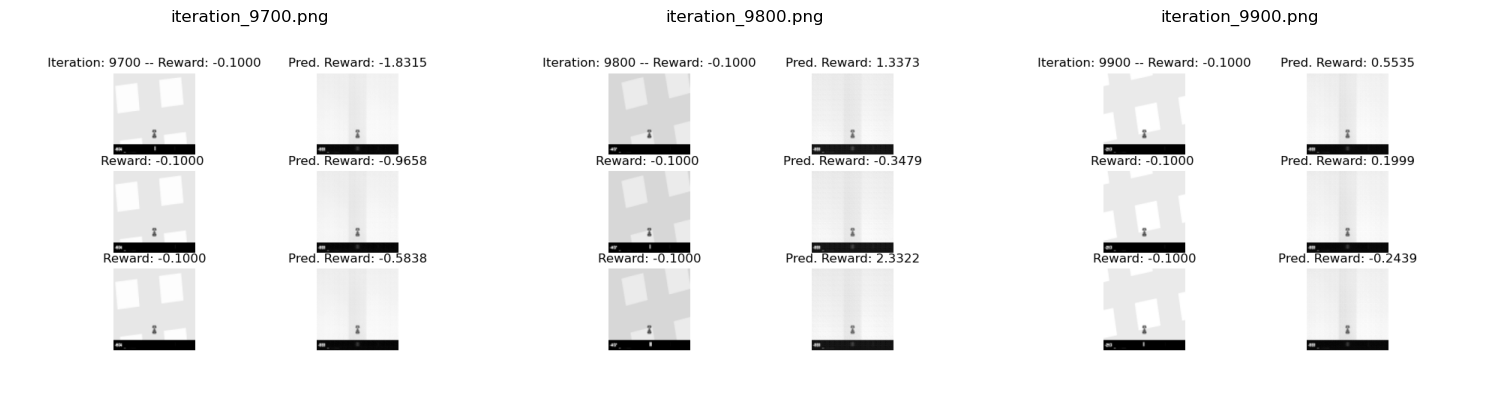

In [121]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

def _display_latest_reconstruction_grid(max_images: int = 3):
    recon_dir = Path("reconstructions")
    if not recon_dir.exists():
        return False

    image_paths = sorted(recon_dir.glob("*.png"))
    if not image_paths:
        return False

    images_to_show = image_paths[-max_images:]
    n_cols = len(images_to_show)
    plt.figure(figsize=(5 * n_cols, 5))
    for idx, path in enumerate(images_to_show, start=1):
        img = plt.imread(path)
        plt.subplot(1, n_cols, idx)
        plt.imshow(img)
        plt.title(f"{path.name}")
        plt.axis("off")
    plt.tight_layout()
    return True

def _generate_inline_reconstruction(batch_size: int = 1, seq_len: int = 4):
    buffer = trainer.agent.buffer
    available = min(buffer.idx, buffer.buffer_size)
    if available <= seq_len:
        print("Buffer does not have enough samples yet. Collect more data first.")
        return

    obs_np, actions_np, rewards_np, dones_np = buffer.sample(batch_size, seq_len)

    device = trainer.device
    obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
    actions = torch.tensor(actions_np, dtype=torch.long, device=device)
    dones = torch.tensor(dones_np, dtype=torch.float32, device=device)

    obs_reshaped = obs.reshape(-1, *obs.shape[2:]).permute(0, 3, 1, 2)
    with torch.no_grad():
        encoded = trainer.world_model.encoder(obs_reshaped)
        encoded = encoded.reshape(batch_size, seq_len, -1)
        actions_one_hot = F.one_hot(actions, num_classes=trainer.world_model.action_dim).float()
        rollout = trainer.world_model.generate_rollout(actions_one_hot, obs=encoded, dones=dones)
        hiddens, _, posterior_states, _, _, _, _ = rollout
        decoded = trainer.world_model.decoder(
            hiddens.reshape(batch_size * seq_len, -1),
            posterior_states.reshape(batch_size * seq_len, -1)
        )
        decoded = decoded.reshape_as(obs)

    obs_to_plot = obs_np[0]
    decoded_to_plot = decoded.cpu().numpy()[0]
    rewards_to_plot = rewards_np[0]

    channels = obs_to_plot.shape[-1]
    is_grayscale = channels == 1

    fig, axes = plt.subplots(seq_len, 3, figsize=(12, 3 * seq_len))
    for t in range(seq_len):
        original_frame = obs_to_plot[t]
        reconstructed_frame = decoded_to_plot[t]
        reward_value = rewards_to_plot[t, 0]

        if is_grayscale:
            original_frame = original_frame[..., 0]
            reconstructed_frame = reconstructed_frame[..., 0]
            cmap = "gray"
        else:
            cmap = None

        axes[t, 0].imshow(original_frame, cmap=cmap)
        axes[t, 0].set_title(f"Original t={t}")
        axes[t, 0].axis("off")

        axes[t, 1].imshow(reconstructed_frame, cmap=cmap)
        axes[t, 1].set_title("Reconstruction")
        axes[t, 1].axis("off")

        axes[t, 2].plot(rewards_to_plot[: t + 1], marker="o")
        axes[t, 2].set_title("Reward trajectory")
        axes[t, 2].set_xlabel("Step")
        axes[t, 2].set_ylabel("Reward")

    plt.tight_layout()
    plt.show()

if not _display_latest_reconstruction_grid():
    print("No pre-rendered reconstructions found. Generating a fresh visualization from the buffer...")
    _generate_inline_reconstruction()

Saved 400 frames to videos/trajectory.gif (fps=12) at 256x256.



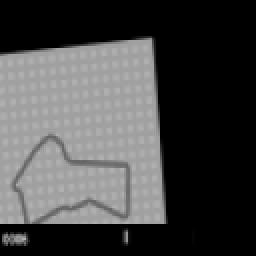

PosixPath('videos/trajectory.gif')

: 

: 

: 

In [ ]:
import numpy as np
import imageio.v2 as imageio
from pathlib import Path
from IPython.display import HTML, display
import base64

def create_trajectory_animation(max_frames: int = 400, fps: int = 15, output_name: str = "trajectory.gif", start_idx: int = 0, embed_inline: bool = True, scale: int = 2):
    buffer = trainer.agent.buffer
    total_frames = min(buffer.idx, buffer.buffer_size)
    if total_frames <= 1:
        print("Buffer does not contain enough frames yet. Collect more data first.")
        return None

    end_idx = min(total_frames, start_idx + max_frames)
    frames = buffer.obs_buffer[start_idx:end_idx]
    if frames.size == 0:
        print("Requested frame range is empty. Adjust start_idx or max_frames.")
        return None

    frames_uint8 = np.clip(frames * 255.0, 0, 255).astype(np.uint8)
    if frames_uint8.shape[-1] == 1:
        frames_uint8 = frames_uint8[..., 0]

    if scale is not None and scale > 1:
        frames_uint8 = np.repeat(frames_uint8, scale, axis=1)
        frames_uint8 = np.repeat(frames_uint8, scale, axis=2)

    frame_height = frames_uint8.shape[1]
    frame_width = frames_uint8.shape[2]

    output_dir = Path("videos")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / output_name

    imageio.mimsave(output_path, frames_uint8, duration=1.0 / max(fps, 1))
    print(f"Saved {len(frames_uint8)} frames to {output_path} (fps={fps}) at {frame_height}x{frame_width}.")

    if embed_inline:
        with open(output_path, "rb") as fh:
            encoded = base64.b64encode(fh.read()).decode("ascii")
        display(HTML(f'<img src="data:image/gif;base64,{encoded}" />'))
    else:
        print("Animation saved. Use the following path to download or view:")
        print(output_path)

    return output_path

# Generate and display an animation for the collected trajectory
create_trajectory_animation(max_frames=400, fps=12, output_name="trajectory.gif", start_idx=0, embed_inline=True, scale=2)


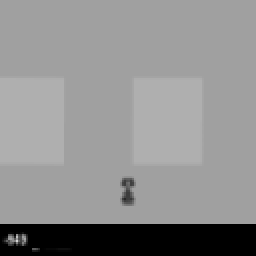


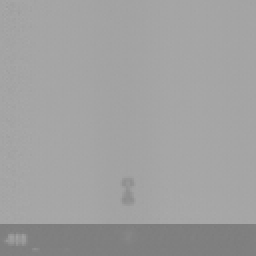

In [123]:
import numpy as np
import torch
import torch.nn.functional as F
import imageio.v2 as imageio
from pathlib import Path
from IPython.display import HTML, display
import base64

def _prepare_frames(frames: np.ndarray, scale: int = 2):
    frames = np.clip(frames, 0.0, 1.0)
    if frames.ndim == 3:
        frames = frames[..., None]
    if frames.shape[-1] == 1:
        frames = np.repeat(frames, 3, axis=-1)
    frames_uint8 = (frames * 255.0).astype(np.uint8)
    if scale > 1:
        frames_uint8 = np.repeat(frames_uint8, scale, axis=1)
        frames_uint8 = np.repeat(frames_uint8, scale, axis=2)
    return frames_uint8

def _frames_to_gif_html(frames: np.ndarray, output_path: Path, fps: int = 10, scale: int = 2):
    frames_uint8 = _prepare_frames(frames, scale)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    imageio.mimsave(output_path, frames_uint8, duration=1.0 / max(fps, 1))
    with open(output_path, "rb") as fh:
        encoded = base64.b64encode(fh.read()).decode("ascii")
    return HTML(f'<img src="data:image/gif;base64,{encoded}" />'), frames_uint8.shape[1], frames_uint8.shape[2]

def visualize_real_and_imagined_trajectories(seq_len: int = 60, fps: int = 10, scale: int = 2):
    buffer = trainer.agent.buffer
    available = min(buffer.idx, buffer.buffer_size)
    if available <= seq_len:
        raise RuntimeError(f"Buffer only contains {available} frames; collect more than {seq_len} to visualize.")

    start_idx = np.random.randint(0, available - seq_len)
    real_frames = buffer.obs_buffer[start_idx:start_idx + seq_len]
    real_html, real_h, real_w = _frames_to_gif_html(real_frames, Path("videos/real_trajectory.gif"), fps=fps, scale=scale)

    device = trainer.device
    action_dim = trainer.world_model.action_dim
    actions_idx = torch.randint(0, action_dim, (1, seq_len), device=device)
    actions_one_hot = F.one_hot(actions_idx, num_classes=action_dim).float()

    if not hasattr(trainer.world_model.dynamics, "embedding_dim"):
        trainer.world_model.dynamics.embedding_dim = trainer.world_model.embedding_dim

    hiddens, prior_states, _, prior_means, prior_logvars, posterior_means, posterior_logvars = trainer.world_model.generate_rollout(actions_one_hot)
    decoded = trainer.world_model.decoder(
        hiddens.reshape(-1, hiddens.shape[-1]),
        prior_states.reshape(-1, prior_states.shape[-1])
)
    decoded = torch.sigmoid(decoded)
    decoded = decoded.reshape(1, seq_len, *decoded.shape[1:])
    imagined_frames = decoded.squeeze(0).permute(0, 2, 3, 1).detach().cpu().numpy()
    imagined_html, imag_h, imag_w = _frames_to_gif_html(imagined_frames, Path("videos/imagined_trajectory.gif"), fps=fps, scale=scale)

    display(HTML(f"<h3>Real experience trajectory ({seq_len} steps, {real_h}x{real_w})</h3>"))
    display(real_html)
    display(HTML(f"<h3>Latent imagination trajectory ({seq_len} steps, {imag_h}x{imag_w})</h3>"))
    display(imagined_html)

visualize_real_and_imagined_trajectories(seq_len=60, fps=10, scale=2)